# Layer 1 — Hedonic Lease Rate Model (Dallas Office)

Predicts log(Lease Rate $/sqft/yr) from property attributes, FRED macro indicators,
and GreenStreet submarket quality scores.  
Four models are benchmarked: **Ridge**, **Lasso**, **Random Forest**, **LightGBM**.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
import shap

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR = './'
TARGET   = 'Lease rate'

## 2. Load & Parse

In [2]:
df = pd.read_csv(DATA_DIR + 'office_preprocessed.csv')
print(f'Loaded: {df.shape}')

Loaded: (398, 70)


In [3]:
# ── 2.1  Parse object columns that contain numbers ───────────────────────
def strip_numeric(val):
    if pd.isna(val):
        return np.nan
    s = re.sub(r'[$,]', '', str(val)).strip()
    try:
        return float(s)
    except ValueError:
        return np.nan

df['building_sqft']       = df['Building sqft'].apply(strip_numeric)
df['sold_price']          = df['Sold price'].apply(strip_numeric)
df['sold_price_per_sqft'] = df['Sold price/sqft'].apply(strip_numeric)
df['lot_size_sqft']       = df['Lot size sqft'].apply(strip_numeric)
df['sold_price_per_acre'] = df['Sold price/acre'].apply(strip_numeric)

print('Parsed columns:')
for c in ['building_sqft','sold_price','sold_price_per_sqft','lot_size_sqft','sold_price_per_acre']:
    print(f'  {c}: {df[c].notna().sum()} non-null, median = {df[c].median():.0f}')

# Fill NAs with median
for c in ['building_sqft','sold_price','sold_price_per_sqft','lot_size_sqft','sold_price_per_acre']:
    df[c] = df[c].fillna(df[c].median())

Parsed columns:
  building_sqft: 398 non-null, median = 13982
  sold_price: 398 non-null, median = 1822765
  sold_price_per_sqft: 398 non-null, median = 127
  lot_size_sqft: 398 non-null, median = 62417
  sold_price_per_acre: 398 non-null, median = 1675371


In [4]:
# ── 2.2  Parse date and derive time features ──────────────────────────────
df['date_sold'] = pd.to_datetime(df['date_sold'], errors='coerce')
df['sale_year']    = df['date_sold'].dt.year
df['sale_quarter'] = df['date_sold'].dt.quarter

# Sort by date for temporal split
df = df.sort_values('date_sold').reset_index(drop=True)
print(f'Date range: {df["date_sold"].min().date()} → {df["date_sold"].max().date()}')
print(f'Shape: {df.shape}')

Date range: 2000-01-06 → 2026-03-03
Shape: (398, 77)


## 3. Feature Engineering

In [5]:
# ── 3.1  Ordinal encoding for GreenStreet qualitative columns ─────────────
GRADE_ORDER = ['C', 'C+', 'B-', 'B', 'B+', 'A-', 'A', 'A+', 'A++']
BARRIERS    = {'Very Low': 1, 'Low': 2, 'Average': 3, 'High': 4, 'Very High': 5}
FRIENDLY    = {'Unfriendly': 1, 'Average': 2, 'Friendly': 3, 'Very Friendly': 4}
RISK        = {'Very Low': 1, 'Low': 2, 'Average': 3, 'High': 4, 'Very High': 5}

df['gs_grade_ord']       = df['gs_submarket_grade'].map({g: i for i, g in enumerate(GRADE_ORDER)})
df['gs_barriers_ord']    = df['gs_supply_barriers'].map(BARRIERS)
df['gs_friendliness_ord']= df['gs_business_friendliness'].map(FRIENDLY)
df['gs_risk_ord']        = df['gs_climate_event_risk'].map(RISK)

# Encode Rent bumps as binary
df['rent_bumps_bin'] = (df['Rent bumps'].str.lower() == 'yes').astype(int)

print('Ordinal-encoded GreenStreet columns:')
print(df[['gs_submarket_grade','gs_grade_ord','gs_supply_barriers','gs_barriers_ord']].drop_duplicates().sort_values('gs_grade_ord').to_string(index=False))

Ordinal-encoded GreenStreet columns:
gs_submarket_grade  gs_grade_ord gs_supply_barriers  gs_barriers_ord
                 B             3           Very Low                1
                B+             4           Very Low                1
                A-             5           Very Low                1
                A-             5                Low                2
                 A             6           Very Low                1
               A++             8            Average                3


In [6]:
# ── 3.2  Select and categorise features ───────────────────────────────────

# Numeric — property
NUM_PROPERTY = [
    'building_sqft', 'sold_price', 'sold_price_per_sqft', 'sold_price_per_acre',
    'lot_size_sqft', 'Lot size acres', 'Number of units', 'Building count',
    'Year built', 'sale_year', 'sale_quarter',
    'Interest rate', 'Total monthly rate', 'Loan amount',
]

# Numeric — FRED macro
NUM_FRED = [
    'GDPC1', 'UNRATE', 'Unemployment Rate Squared', 'PAYEMS',
    'FEDFUNDS', 'MORTGAGE30US', 'DGS10', 'DGS2', 'T10Y2Y', 'DFII10',
    'CPIAUCSL', 'CPI Inflation QoQ Ann (%)', 'GDP Growth QoQ Ann (%)',
    'US Employment Growth QoQ (%)', 'M2SL', 'M2V', 'NFCI',
    'BAMLC0A4CBBB', 'DTWEXBGS', 'Mortgage Debt / GDP',
    'SUBLPDRCSC', 'CREACBW027SBOG', 'Bank CRE Loan Growth QoQ (%)',
]

# Numeric — GreenStreet
NUM_GS = [
    'gs_grade_ord', 'gs_barriers_ord', 'gs_friendliness_ord', 'gs_risk_ord',
    'gs_submarket_grade_rank', 'gs_desirability_index',
    'gs_median_household_income', 'gs_pct_college_degree',
    'gs_pct_office_establishments', 'gs_population_density', 'gs_distance_to_cbd',
]

# Categorical (low cardinality → OHE)
CAT_COLS = [
    'Property subtype', 'Lease type', 'Loan type',
    'Tenancy', 'Transaction Type', 'County', 'gs_submarket',
]

NUM_ALL = NUM_PROPERTY + NUM_FRED + NUM_GS

print(f'Numeric features  : {len(NUM_ALL)}  ({len(NUM_PROPERTY)} property + {len(NUM_FRED)} FRED + {len(NUM_GS)} GreenStreet)')
print(f'Categorical features: {len(CAT_COLS)}')
print(f'Total input features: {len(NUM_ALL) + len(CAT_COLS)}')

Numeric features  : 48  (14 property + 23 FRED + 11 GreenStreet)
Categorical features: 7
Total input features: 55


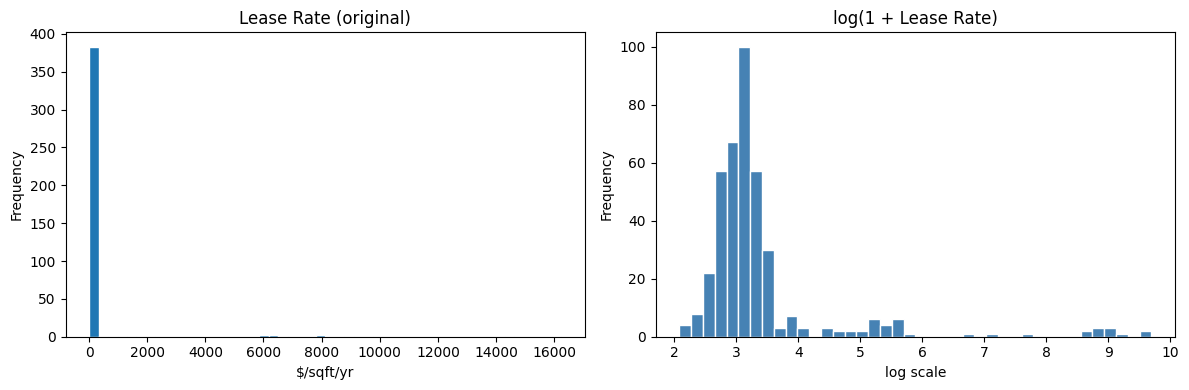

log-target skewness: 3.447  (original: 7.131)


In [7]:
# ── 3.3  Log-transform target ──────────────────────────────────────────────
df['log_lease_rate'] = np.log1p(df[TARGET])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[TARGET].plot.hist(bins=50, ax=axes[0], edgecolor='white')
axes[0].set_title('Lease Rate (original)')
axes[0].set_xlabel('$/sqft/yr')

df['log_lease_rate'].plot.hist(bins=40, ax=axes[1], edgecolor='white', color='steelblue')
axes[1].set_title('log(1 + Lease Rate)')
axes[1].set_xlabel('log scale')

plt.tight_layout()
plt.show()
print(f"log-target skewness: {df['log_lease_rate'].skew():.3f}  (original: {df[TARGET].skew():.3f})")

## 4. Temporal Train / Test Split

Data is sorted by `date_sold`.  The most recent **20%** of transactions (≈ 80 deals)
form the held-out test set, simulating a real deployment scenario.

In [8]:
LOG_TARGET = 'log_lease_rate'
FEATURES   = NUM_ALL + CAT_COLS

X = df[FEATURES].copy()
y = df[LOG_TARGET].copy()

split_idx  = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train : {len(X_train)} rows  ({df["date_sold"].iloc[0].date()} → {df["date_sold"].iloc[split_idx-1].date()})')
print(f'Test  : {len(X_test)}  rows  ({df["date_sold"].iloc[split_idx].date()} → {df["date_sold"].iloc[-1].date()})')

Train : 318 rows  (2000-01-06 → 2023-07-28)
Test  : 80  rows  (2023-08-07 → 2026-03-03)


## 5. Preprocessing Pipeline

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUM_ALL),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS),
    ],
    remainder='drop'
)

# Fit on train only
preprocessor.fit(X_train)
X_train_t = preprocessor.transform(X_train)
X_test_t  = preprocessor.transform(X_test)

n_features_out = X_train_t.shape[1]
print(f'Features after encoding: {n_features_out}')
print(f'Train matrix: {X_train_t.shape}  |  Test matrix: {X_test_t.shape}')

Features after encoding: 119
Train matrix: (318, 119)  |  Test matrix: (80, 119)


## 6. Model Training & Evaluation

All models are evaluated with **5-fold TimeSeriesSplit CV** on the training set  
and on the held-out test set.  Metrics are reported on the **log scale** (primary)  
and the **original $/sqft/yr scale** (RMSE and MAE via `expm1`).

In [10]:
def eval_model(name, y_true, y_pred_log):
    """Return metrics dict on both log and original scale."""
    rmse_log = np.sqrt(mean_squared_error(y_true, y_pred_log))
    mae_log  = mean_absolute_error(y_true, y_pred_log)
    r2       = r2_score(y_true, y_pred_log)

    y_orig      = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred_log)
    rmse_orig   = np.sqrt(mean_squared_error(y_orig, y_pred_orig))
    mae_orig    = mean_absolute_error(y_orig, y_pred_orig)
    mape        = np.mean(np.abs((y_orig - y_pred_orig) / y_orig)) * 100

    return {
        'Model': name,
        'R²':    round(r2, 4),
        'RMSE (log)': round(rmse_log, 4),
        'MAE (log)':  round(mae_log, 4),
        'RMSE ($/sf)': round(rmse_orig, 2),
        'MAE ($/sf)':  round(mae_orig, 2),
        'MAPE (%)':    round(mape, 2),
    }

tscv = TimeSeriesSplit(n_splits=5)
results = []
models_fitted = {}

In [11]:
# ── 6.1  Ridge ────────────────────────────────────────────────────────────
alphas = np.logspace(-2, 4, 60)
ridge_cv = RidgeCV(alphas=alphas, cv=tscv, scoring='r2')
ridge_cv.fit(X_train_t, y_train)

print(f'Best alpha (Ridge): {ridge_cv.alpha_:.4f}')

ridge_pred = ridge_cv.predict(X_test_t)
results.append(eval_model('Ridge', y_test, ridge_pred))
models_fitted['Ridge'] = ridge_cv
print(results[-1])

Best alpha (Ridge): 57.9044
{'Model': 'Ridge', 'R²': 0.3633, 'RMSE (log)': np.float64(0.9675), 'MAE (log)': 0.5279, 'RMSE ($/sf)': np.float64(1290.7), 'MAE ($/sf)': 234.05, 'MAPE (%)': np.float64(45.09)}


In [12]:
# ── 6.2  Lasso ────────────────────────────────────────────────────────────
lasso_cv = LassoCV(alphas=np.logspace(-4, 2, 60), cv=tscv, max_iter=10000)
lasso_cv.fit(X_train_t, y_train)

print(f'Best alpha (Lasso): {lasso_cv.alpha_:.6f}')
print(f'Non-zero coefficients: {(lasso_cv.coef_ != 0).sum()} / {len(lasso_cv.coef_)}')

lasso_pred = lasso_cv.predict(X_test_t)
results.append(eval_model('Lasso', y_test, lasso_pred))
models_fitted['Lasso'] = lasso_cv
print(results[-1])

Best alpha (Lasso): 0.226951
Non-zero coefficients: 1 / 119
{'Model': 'Lasso', 'R²': 0.3373, 'RMSE (log)': np.float64(0.987), 'MAE (log)': 0.5538, 'RMSE ($/sf)': np.float64(1541.63), 'MAE ($/sf)': 267.17, 'MAPE (%)': np.float64(49.61)}


In [13]:
# ── 6.3  Random Forest ────────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=400, max_depth=None, min_samples_leaf=3,
    max_features=0.33, n_jobs=-1, random_state=42
)
rf.fit(X_train_t, y_train)

rf_cv_r2 = cross_val_score(rf, X_train_t, y_train, cv=tscv, scoring='r2')
print(f'RF CV R² (mean ± std): {rf_cv_r2.mean():.4f} ± {rf_cv_r2.std():.4f}')

rf_pred = rf.predict(X_test_t)
results.append(eval_model('Random Forest', y_test, rf_pred))
models_fitted['Random Forest'] = rf
print(results[-1])

RF CV R² (mean ± std): 0.0154 ± 0.6577
{'Model': 'Random Forest', 'R²': 0.5013, 'RMSE (log)': np.float64(0.8562), 'MAE (log)': 0.5259, 'RMSE ($/sf)': np.float64(1593.73), 'MAE ($/sf)': 272.36, 'MAPE (%)': np.float64(51.74)}


In [14]:
# ── 6.4  LightGBM ─────────────────────────────────────────────────────────
lgbm = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=31,
    min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbose=-1
)
lgbm.fit(
    X_train_t, y_train,
    eval_set=[(X_test_t, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
)

print(f'Best iteration: {lgbm.best_iteration_}')

lgbm_pred = lgbm.predict(X_test_t)
results.append(eval_model('LightGBM', y_test, lgbm_pred))
models_fitted['LightGBM'] = lgbm
print(results[-1])

Best iteration: 24
{'Model': 'LightGBM', 'R²': 0.2682, 'RMSE (log)': np.float64(1.0372), 'MAE (log)': 0.6321, 'RMSE ($/sf)': np.float64(1727.42), 'MAE ($/sf)': 295.14, 'MAPE (%)': np.float64(94.6)}


## 7. Model Comparison

In [15]:
results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())
results_df

                  R²  RMSE (log)  MAE (log)  RMSE ($/sf)  MAE ($/sf)  MAPE (%)
Model                                                                         
Ridge         0.3633      0.9675     0.5279    1290.7000    234.0500   45.0900
Lasso         0.3373      0.9870     0.5538    1541.6300    267.1700   49.6100
Random Forest 0.5013      0.8562     0.5259    1593.7300    272.3600   51.7400
LightGBM      0.2682      1.0372     0.6321    1727.4200    295.1400   94.6000


,R²,RMSE (log),MAE (log),RMSE ($/sf),MAE ($/sf),MAPE (%)
Model,,,,,,
Ridge,0.3633,0.9675,0.5279,1290.7000,234.0500,45.0900
Lasso,0.3373,0.9870,0.5538,1541.6300,267.1700,49.6100
Random Forest,0.5013,0.8562,0.5259,1593.7300,272.3600,51.7400
LightGBM,0.2682,1.0372,0.6321,1727.4200,295.1400,94.6000


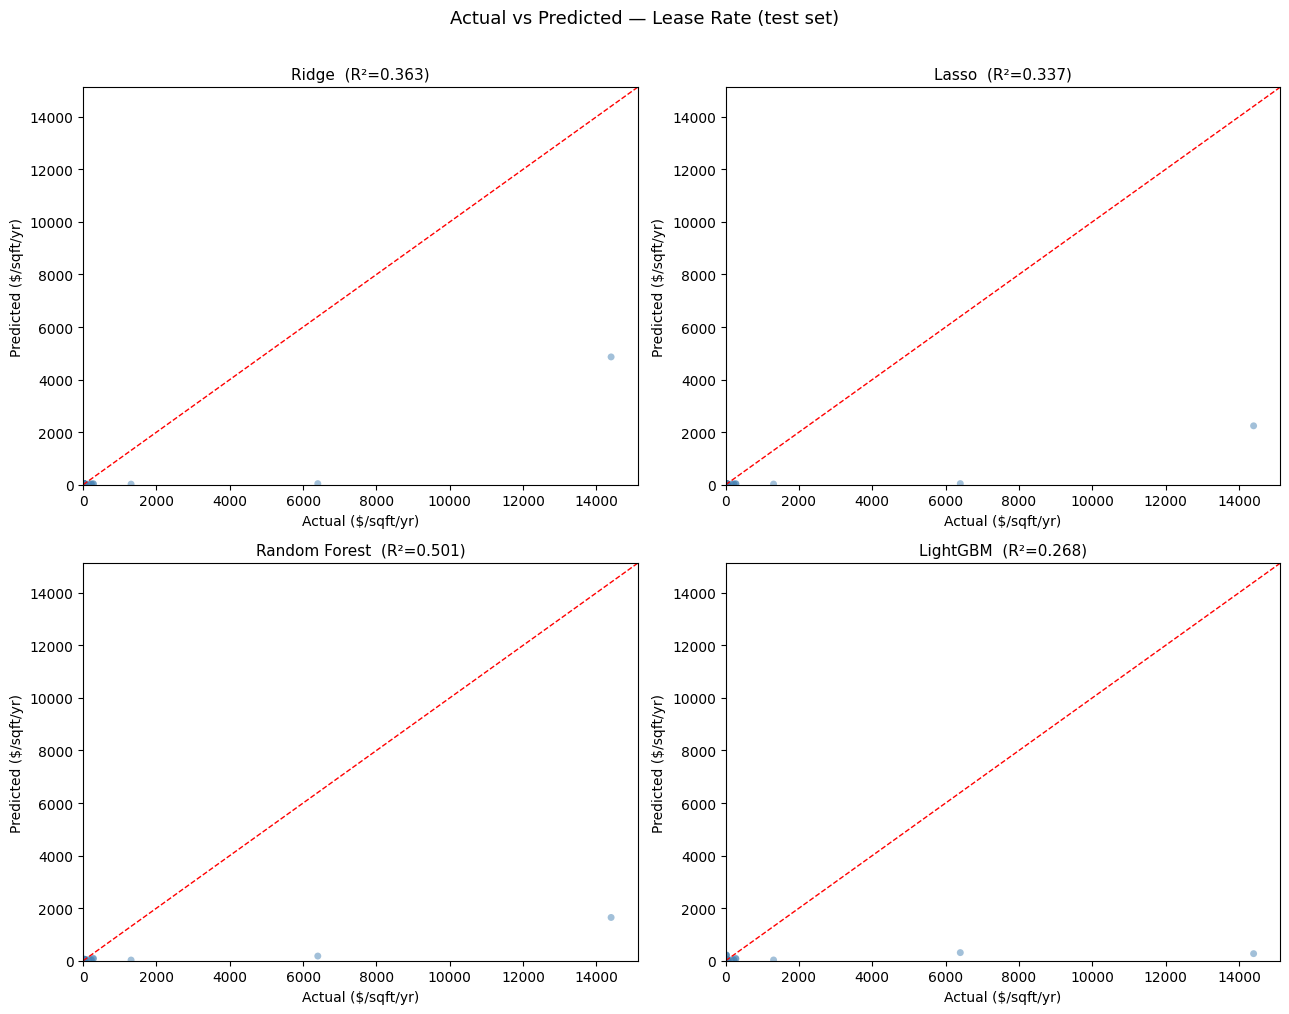

In [16]:
# ── Actual vs Predicted plot for all 4 models ─────────────────────────────
all_preds = {
    'Ridge':         ridge_cv.predict(X_test_t),
    'Lasso':         lasso_cv.predict(X_test_t),
    'Random Forest': rf.predict(X_test_t),
    'LightGBM':      lgbm.predict(X_test_t),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (name, pred_log) in zip(axes, all_preds.items()):
    actual_orig = np.expm1(y_test)
    pred_orig   = np.expm1(pred_log)
    r2          = r2_score(y_test, pred_log)

    ax.scatter(actual_orig, pred_orig, alpha=0.5, s=25, edgecolors='none', color='steelblue')
    lim = max(actual_orig.max(), pred_orig.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1)
    ax.set_title(f'{name}  (R²={r2:.3f})', fontsize=11)
    ax.set_xlabel('Actual ($/sqft/yr)')
    ax.set_ylabel('Predicted ($/sqft/yr)')
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)

plt.suptitle('Actual vs Predicted — Lease Rate (test set)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

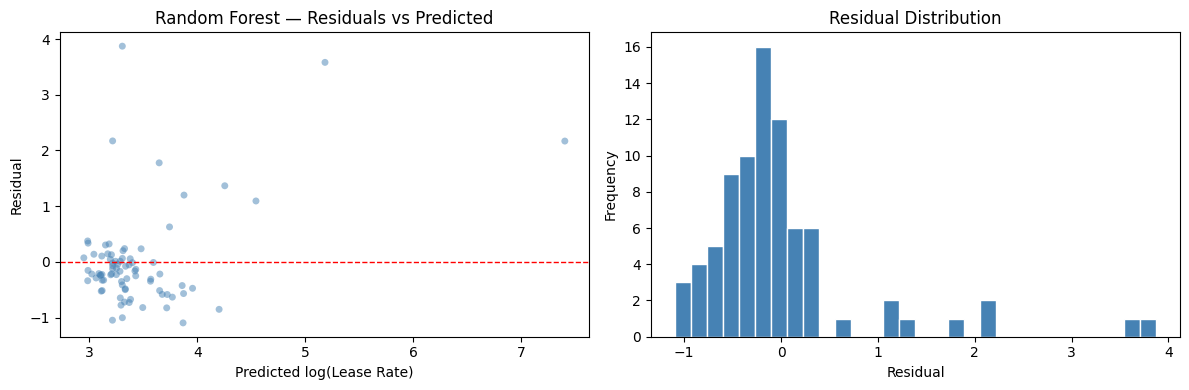

Best model: Random Forest  |  Test R² = 0.5013


In [17]:
# Best model residuals
best_name = results_df['R²'].idxmax()
best_pred = all_preds[best_name]
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(best_pred, residuals, alpha=0.5, s=25, edgecolors='none', color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted log(Lease Rate)')
axes[0].set_ylabel('Residual')
axes[0].set_title(f'{best_name} — Residuals vs Predicted')

residuals.plot.hist(bins=30, ax=axes[1], edgecolor='white', color='steelblue')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()
print(f'Best model: {best_name}  |  Test R² = {results_df.loc[best_name, "R²"]}')

## 8. Feature Importance

Two views: **LightGBM built-in gain importance** and **SHAP values** (model-agnostic).

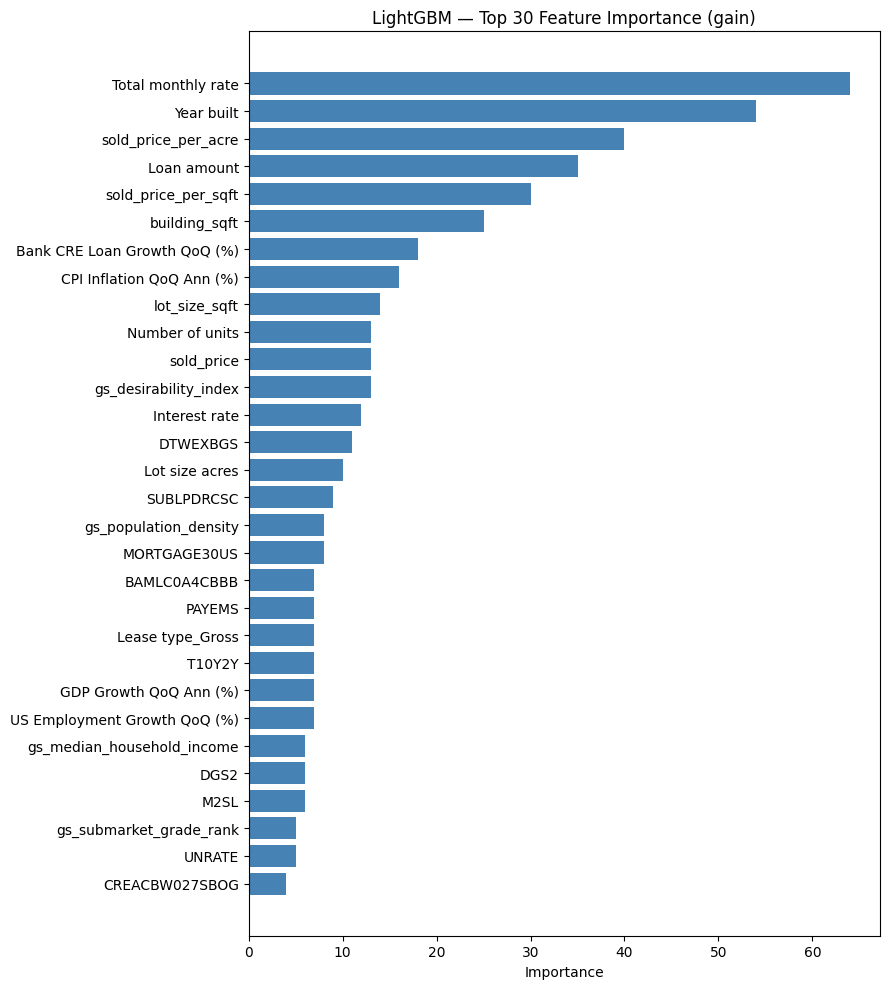

Top 15 features:
                     feature  importance
          Total monthly rate          64
                  Year built          54
         sold_price_per_acre          40
                 Loan amount          35
         sold_price_per_sqft          30
               building_sqft          25
Bank CRE Loan Growth QoQ (%)          18
   CPI Inflation QoQ Ann (%)          16
               lot_size_sqft          14
             Number of units          13
                  sold_price          13
       gs_desirability_index          13
               Interest rate          12
                    DTWEXBGS          11
              Lot size acres          10


In [18]:
# ── 8.1  LightGBM feature importance (gain) ───────────────────────────────
ohe_names = preprocessor.named_transformers_['cat'].get_feature_names_out(CAT_COLS).tolist()
feat_names = NUM_ALL + ohe_names

imp_df = pd.DataFrame({
    'feature':    feat_names,
    'importance': lgbm.feature_importances_,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 10))
top30 = imp_df.head(30)
ax.barh(top30['feature'][::-1], top30['importance'][::-1], color='steelblue')
ax.set_title('LightGBM — Top 30 Feature Importance (gain)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 15 features:')
print(imp_df.head(15).to_string(index=False))

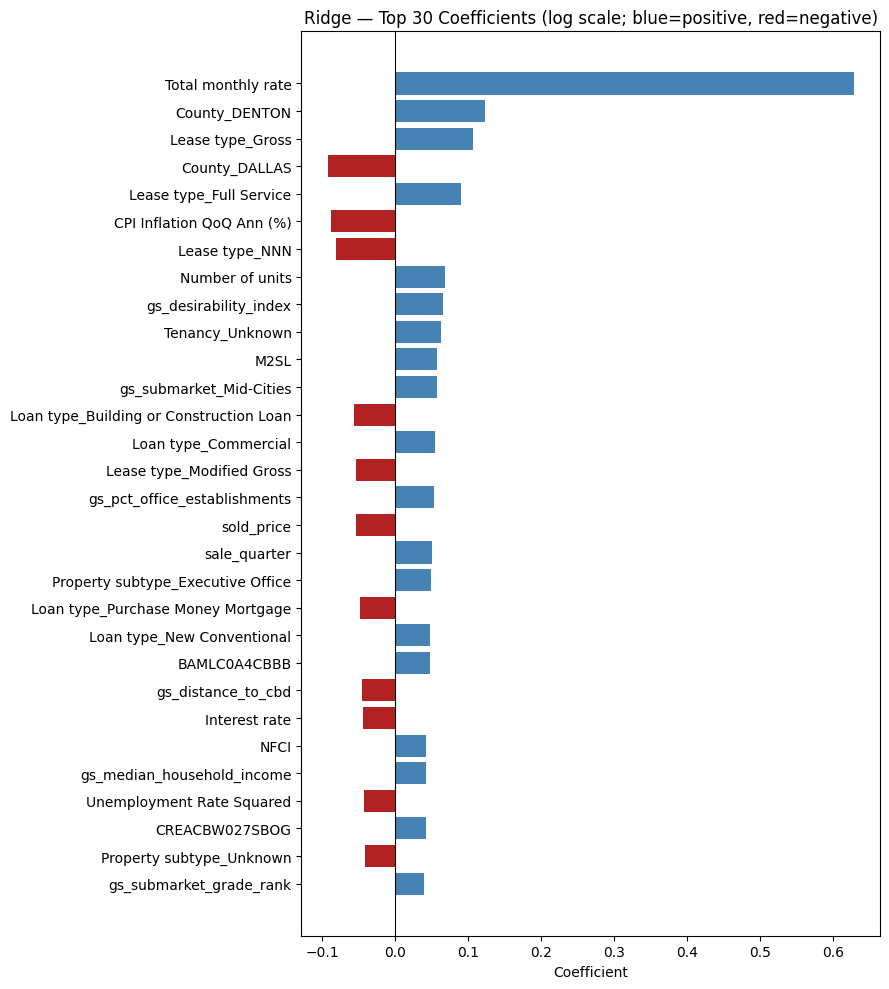

In [19]:
# ── 8.2  Ridge coefficient plot (linear hedonic interpretation) ───────────
ridge_coef = pd.DataFrame({
    'feature': feat_names,
    'coef':    ridge_cv.coef_,
}).assign(abs_coef=lambda d: d['coef'].abs()).sort_values('abs_coef', ascending=False)

fig, ax = plt.subplots(figsize=(9, 10))
top30c = ridge_coef.head(30)
colors = ['steelblue' if c > 0 else 'firebrick' for c in top30c['coef'][::-1]]
ax.barh(top30c['feature'][::-1], top30c['coef'][::-1], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Ridge — Top 30 Coefficients (log scale; blue=positive, red=negative)')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

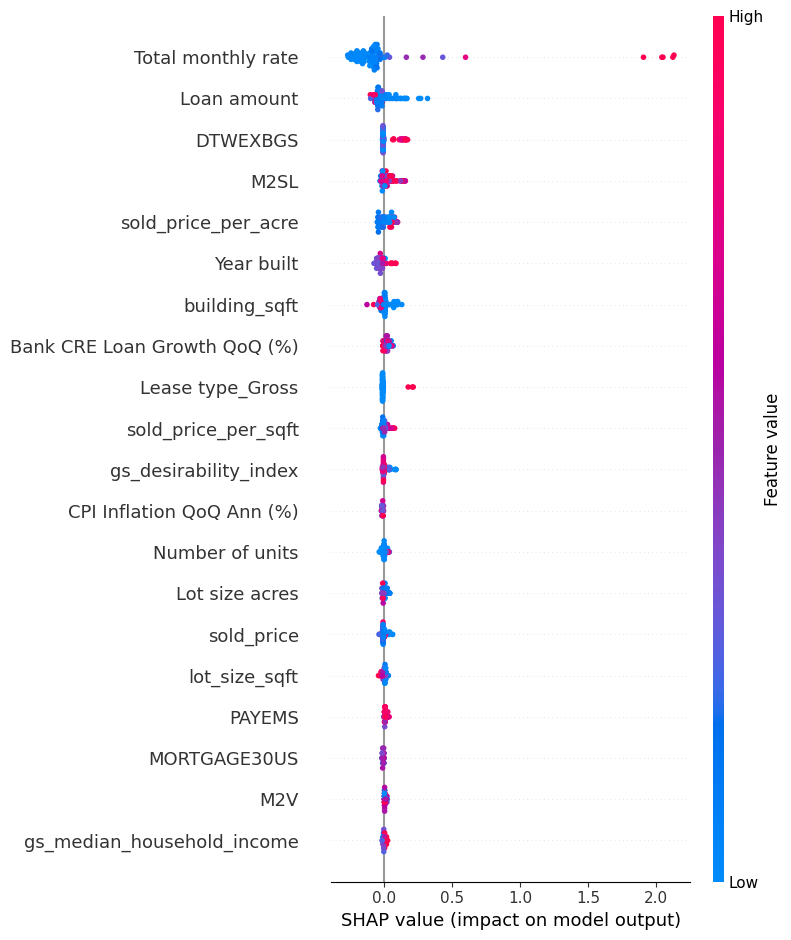

In [20]:
# ── 8.3  SHAP summary plot (LightGBM) ────────────────────────────────────
explainer  = shap.TreeExplainer(lgbm)
shap_vals  = explainer.shap_values(X_test_t)

shap.summary_plot(
    shap_vals, X_test_t,
    feature_names=feat_names,
    max_display=20,
    show=True
)

## 9. Lasso — Selected Features

Lasso performs implicit feature selection. Non-zero coefficients represent the  
minimal set of features needed for a sparse hedonic model.

Lasso selected 1 features out of 119:
           feature   coef
Total monthly rate 0.5377


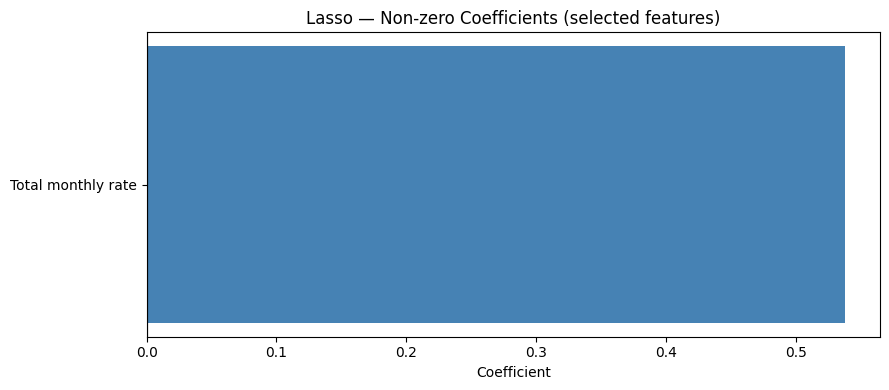

In [21]:
lasso_coef = pd.DataFrame({
    'feature': feat_names,
    'coef':    lasso_cv.coef_,
}).query('coef != 0').assign(abs_coef=lambda d: d['coef'].abs()).sort_values('abs_coef', ascending=False)

print(f'Lasso selected {len(lasso_coef)} features out of {len(feat_names)}:')
print(lasso_coef[['feature','coef']].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, max(4, len(lasso_coef) * 0.35)))
colors = ['steelblue' if c > 0 else 'firebrick' for c in lasso_coef['coef'][::-1]]
ax.barh(lasso_coef['feature'][::-1], lasso_coef['coef'][::-1], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Lasso — Non-zero Coefficients (selected features)')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

## 10. Save Best Model & Artefacts

In [22]:
import joblib, json, os

os.makedirs(DATA_DIR + 'artefacts', exist_ok=True)

# Save preprocessor + best model
joblib.dump(preprocessor,                DATA_DIR + 'artefacts/preprocessor.pkl')
joblib.dump(models_fitted['Ridge'],      DATA_DIR + 'artefacts/ridge.pkl')
joblib.dump(models_fitted['Lasso'],      DATA_DIR + 'artefacts/lasso.pkl')
joblib.dump(models_fitted['Random Forest'], DATA_DIR + 'artefacts/random_forest.pkl')
lgbm.booster_.save_model(               DATA_DIR + 'artefacts/lightgbm.txt')

# Save feature lists
with open(DATA_DIR + 'artefacts/feature_config.json', 'w') as f:
    json.dump({'num': NUM_ALL, 'cat': CAT_COLS, 'target_transform': 'log1p'}, f, indent=2)

# Save test-set results
results_df.to_csv(DATA_DIR + 'artefacts/model_comparison.csv')

print('Saved artefacts:')
for fname in os.listdir(DATA_DIR + 'artefacts'):
    size = os.path.getsize(DATA_DIR + f'artefacts/{fname}')
    print(f'  artefacts/{fname}  ({size/1024:.1f} KB)')

print()
print('=== Final Model Comparison ===')
print(results_df.to_string())

Saved artefacts:
  artefacts/feature_config.json  (1.2 KB)
  artefacts/model_comparison.csv  (0.3 KB)
  artefacts/lasso.pkl  (5.2 KB)
  artefacts/ridge.pkl  (2.2 KB)
  artefacts/lightgbm.txt  (61.7 KB)
  artefacts/preprocessor.pkl  (8.8 KB)
  artefacts/random_forest.pkl  (3238.6 KB)

=== Final Model Comparison ===
                  R²  RMSE (log)  MAE (log)  RMSE ($/sf)  MAE ($/sf)  MAPE (%)
Model                                                                         
Ridge         0.3633      0.9675     0.5279    1290.7000    234.0500   45.0900
Lasso         0.3373      0.9870     0.5538    1541.6300    267.1700   49.6100
Random Forest 0.5013      0.8562     0.5259    1593.7300    272.3600   51.7400
LightGBM      0.2682      1.0372     0.6321    1727.4200    295.1400   94.6000
